# 00 · Quick start

EPDE looks for the differential equation that the data obey. Candidate terms are
built from tokens — the variable, its derivatives, coordinates, sine and cosine,
user fields — and a multiobjective evolutionary search combines them into
equations. The result is a **Pareto front**: equations that trade accuracy against
stability or simplicity in different ways.

This notebook makes one complete run on the simplest problem of the collection, a
forced oscillator with time-dependent damping,

$$u'' + \sin(2t)\,u' + 4u = 1.5\,t, \qquad t \in [0, 16).$$

| step | what it does |
|---|---|
| 1 | creates the search object with all settings |
| 2 | describes the grid and the boundary excluded from fitting |
| 3 | attaches the data and computes derivatives |
| 4 | declares what equations may be built from (token families) |
| 5 | runs the evolutionary search |
| 6 | returns the final Pareto front |

The following notebooks take each step apart: the search settings, preprocessing,
the search space and the search itself, and the evolutionary optimizer.

Displayed outputs are saved examples from earlier executions and do not verify the current version. Re-execute the relevant cells to obtain current results.

In [1]:
import os, sys, time
from pathlib import Path
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')   # before numpy: EPDE is faster single-threaded
os.environ.setdefault('OMP_NUM_THREADS', '1')

# find projects/pic (this notebook lives in projects/pic/notebooks)
PIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'epde_bench').is_dir())
sys.path[:0] = [str(PIC.parent.parent), str(PIC)]
import epde

import numpy as np
import matplotlib.pyplot as plt
from epde_bench import datasets, metrics, load_config, resolve_for_problem, discover
from epde_bench.plotting import plot_problem, plot_front
from epde_bench.truthcheck import check, print_check
from epde_bench.nbcache import cached_run, print_run
import epde_bench.nbcache as notebook_cache
if os.environ.get('EPDE_BENCH_NOTEBOOK_CACHE'):
    notebook_cache.CACHE_DIR = Path(os.environ['EPDE_BENCH_NOTEBOOK_CACHE'])
from epde_bench.env import seed_everything
seed_everything(0)
print('Search cache:', notebook_cache.CACHE_DIR)
from epde_bench.reconstruction import plot_reconstruction
%matplotlib inline
print('EPDE imported; notebook environment ready')

Search cache: <repo>/projects/pic/results/notebook_execution_2026-10-09/search_cache
EPDE imported; notebook environment ready


## The data

In printed equations time is axis 0, so $u'$ appears as du/dx0 and $u''$ as d^2u/dx0^2.

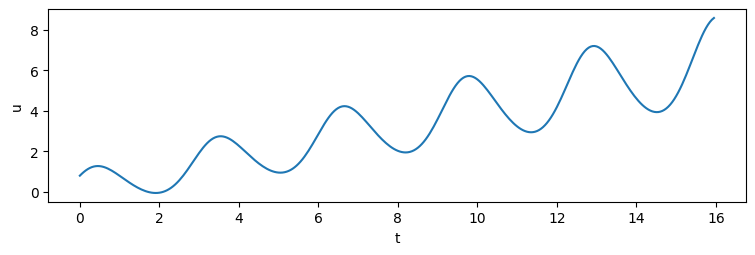

In [2]:
t = np.arange(320) * 0.05
u = np.load(PIC / 'data' / 'ode' / 'ode_data.npy')
plt.figure(figsize=(9, 2.5)); plt.plot(t, u); plt.xlabel('t'); plt.ylabel('u'); plt.show()

## Steps 1–4: search object, domain, data and tokens

EPDE prints progress messages while it builds the pool and runs the evolution;
they are hidden here to keep the notebook readable.

In [3]:
import contextlib, io
from epde import EpdeSearch, GridTokens
from epde_bench.tokens import fixed_trigonometric

config = {
    'domain':        {'boundary_width': 32},                   # points dropped at each end
    'preprocessing': {'default_preprocessor_type': 'FD',       # finite differences
                      'max_deriv_order': [2]},                  # u', u''
    'search_space':  {'data_fun_pow': 3,                        # u, u^2, u^3
                      'deriv_fun_pow': 2,                       # u', (u')^2
                      'equation_terms_max_number': 10,
                      'equation_factors_max_number': {'factors_num': [1, 2], 'probas': [0.65, 0.35]}},
    'evolution':     {'population_size': 16, 'training_epochs': 5},
    'runtime':       {'verbose_params': {'show_iter_idx': False}, 'memory_for_cache': 2},
}
with contextlib.redirect_stdout(io.StringIO()):
    search = EpdeSearch(config=config)
    domain_id, domain = search.createDomain([t], ID=0)
    traj_id, trajectory = search.createTrajectory({'u': u}, domain, cache_id=0)
tokens = [GridTokens(['x'], dimensionality=0, max_power=2),        # t and t^2
          fixed_trigonometric(freq=2.0, dimensionality=0)]          # sin(2t), cos(2t)

## Step 5: the search

In [4]:
t0 = time.time()
with contextlib.redirect_stdout(io.StringIO()):
    search.fit(data=[trajectory], additional_tokens=tokens)
print(f'{time.time() - t0:.1f} s')

10.8 s


## Step 6: the result

The search returns the first Pareto level. Each line is one equation in EPDE's
text form: coefficients, terms and the term chosen as the left-hand side.

In [5]:
search.equations(only_print=True, num=1)



0-th non-dominated level


-3.98448568355491 * u{power: 1.0} + 1.4969734589992256 * x{power: 1.0, dim: 0.0} + -0.9885206385764272 * du/dx0{power: 1.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + 0.0 = d^2u/dx0^2{power: 1.0}
{'max_terms_number': {'optimizable': False, 'value': 10}, 'max_factors_in_term': {'optimizable': False, 'value': {'factors_num': [1, 2], 'probas': [0.65, 0.35]}}, ('sparsity', 'u'): {'optimizable': True, 'value': np.float64(1.0)}} , with objective function values of [1.24921014e-02 8.33618480e-05] 



In [6]:
from epde_bench.runner import pareto_front
front, objectives = pareto_front(search)
problem = datasets.load('ode')
print('true law:', problem.truth[0])
print(metrics.score_run(front, objectives, problem.truth_systems))

true law: -4.0 * u{power: 1.0} + -1.0 * du/dx0{power: 1.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + 1.5 * x{power: 1.0, dim: 0.0} = d^2u/dx0^2{power: 1.0}
{'front_size': 1, 'selected_index': 0, 'success_front': True, 'success_selected': True, 'hamming_min': 0, 'hamming_selected': 0, 'best_index': 0, 'coef_error': 0.005791878178453848}


## Does the equation reproduce the data?

A matching set of terms is one criterion. The other is whether the equation
actually describes the record.

**How to read the comparison.** The upper panel puts the left-hand side of the
selected equation, computed from the data, next to the value the equation
predicts from its right-hand side. For ordinary differential equations written
as "highest derivative = function of the state", the lower panel integrates the
equation from the first point of the record and compares the solution with the
data; there errors accumulate, so this is the stricter test. When the selected
equation is not of that form, only the upper panel is shown. A close match of the
two sides alone does not prove the law: an identity of the record or a rearranged
equation can match as well, so the set of terms is compared with the known law
separately.

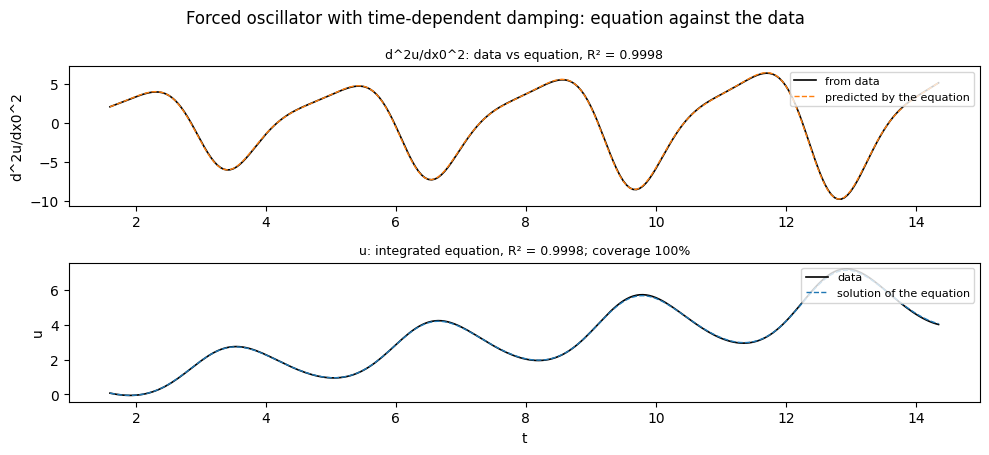

In [7]:
selected_index = metrics.select_compromise(objectives)
if selected_index is None:
    print('No compromise equation: every objective vector is invalid or missing.')
else:
    selected = front[selected_index]
    search_cfg = resolve_for_problem(load_config('ode'), problem)
    fig, scores = plot_reconstruction(problem, selected, search_cfg)
    plt.show()


## The same run in one call

The project's helper package loads any record of the collection with its grids
and known law, merges the shared settings with those of the record and performs
steps 1–5 in one call. The command line and the app run the same code.

In [8]:
search_cfg = resolve_for_problem(load_config('ode'), problem)
with contextlib.redirect_stdout(io.StringIO()):
    search, front, objectives, seconds = discover(problem, search_cfg)
print(f'{seconds:.0f} s')
for system in front:
    print(system[0])

11 s
1.4969734589992256 * x{power: 1.0, dim: 0.0} + -3.9844856835549103 * u{power: 1.0} + -0.9885206385764275 * du/dx0{power: 1.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + 0.0 = d^2u/dx0^2{power: 1.0}
-3.9965325909730756 * u{power: 1.0} + 1.4977090582973742 * x{power: 1.0, dim: 0.0} + 0.01622334714119477 * du/dx0{power: 2.0} + -0.9463965856200313 * du/dx0{power: 1.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + 0.0 = d^2u/dx0^2{power: 1.0}
